In [1]:
import mne
import numpy as np
import pandas as pd

print("Everything is working!")


Everything is working!


In [ ]:
import mne

# Load EEG file
raw = mne.io.read_raw_fif("data/sample_eeg.fif", preload=True)

# Show basic info
raw.info


In [3]:
import mne

raw = mne.io.read_raw_edf("data/sample_eeg.edf", preload=True)
raw.info


FileNotFoundError: File does not exist: "c:\Users\Ali\Desktop\BrainPerturbationProject\notebooks\data\sample_eeg.edf"

In [4]:
import mne

raw = mne.io.read_raw_edf(r"C:\Users\Ali\Desktop\BrainPerturbationProject\data\sample_eeg.edf", preload=True)
raw.info


Extracting EDF parameters from C:\Users\Ali\Desktop\BrainPerturbationProject\data\sample_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

Using matplotlib as 2D backend.


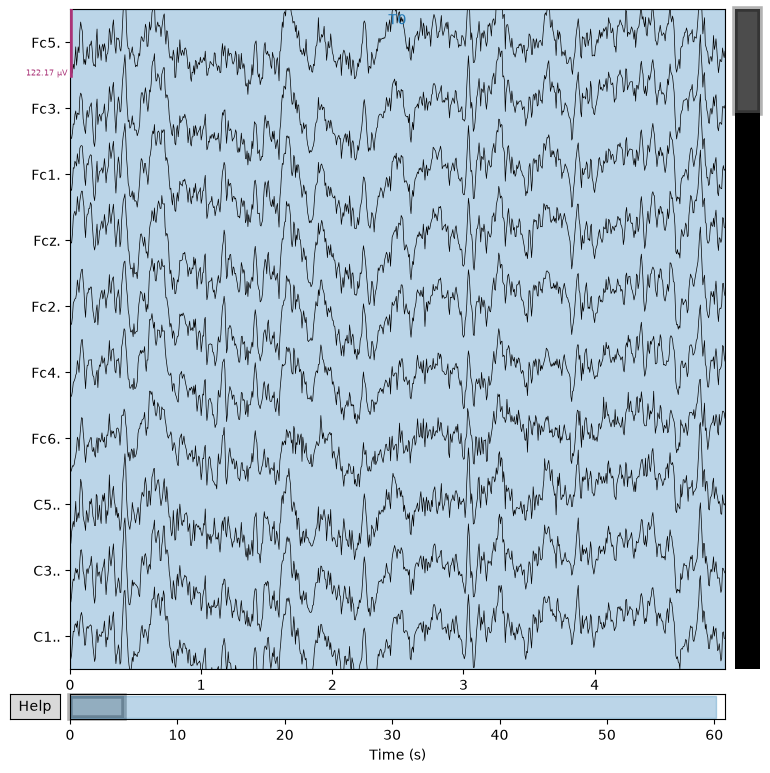

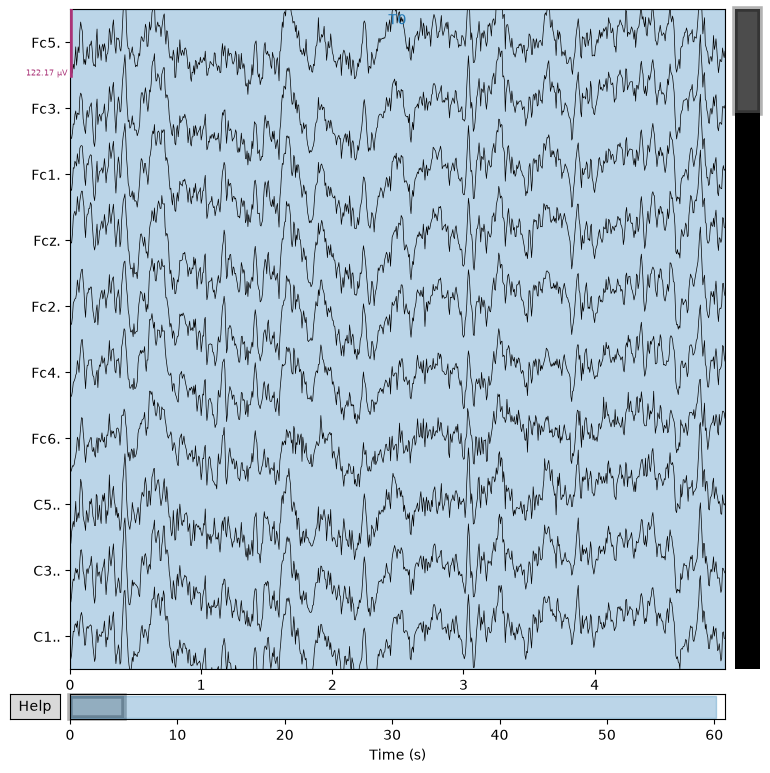

In [5]:
raw.plot(n_channels=10, duration=5, scalings='auto')


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



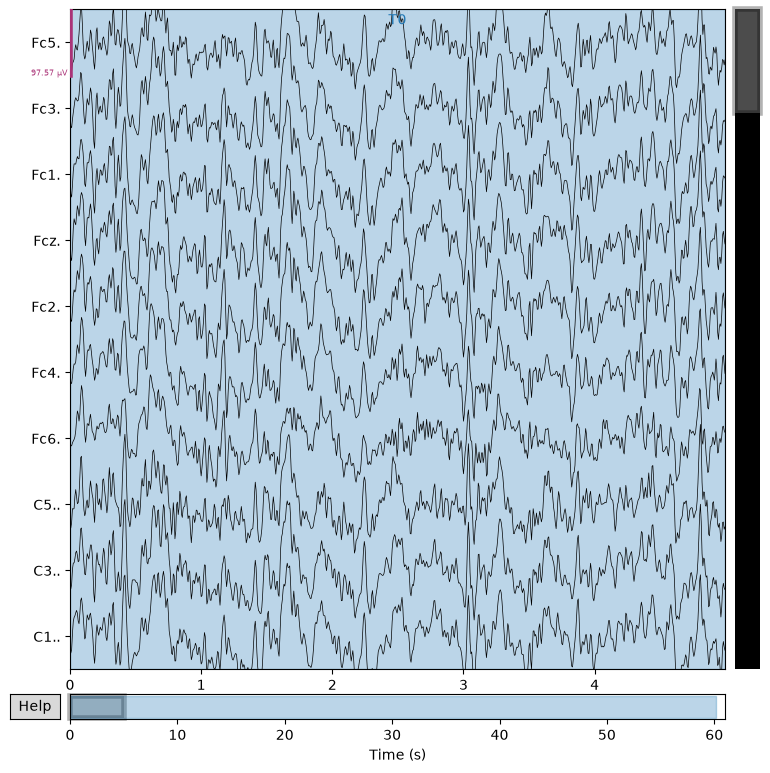

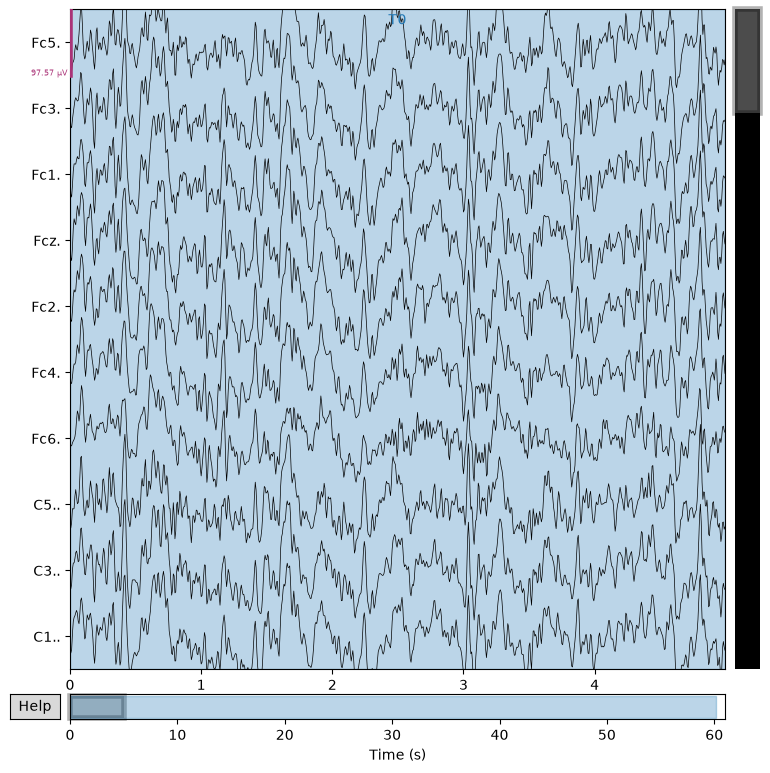

In [6]:
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0)
raw_filtered.plot(n_channels=10, duration=5, scalings='auto')


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


C:\Users\Ali\AppData\Local\Temp\ipykernel_2340\794898365.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=80)
c:\Users\Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


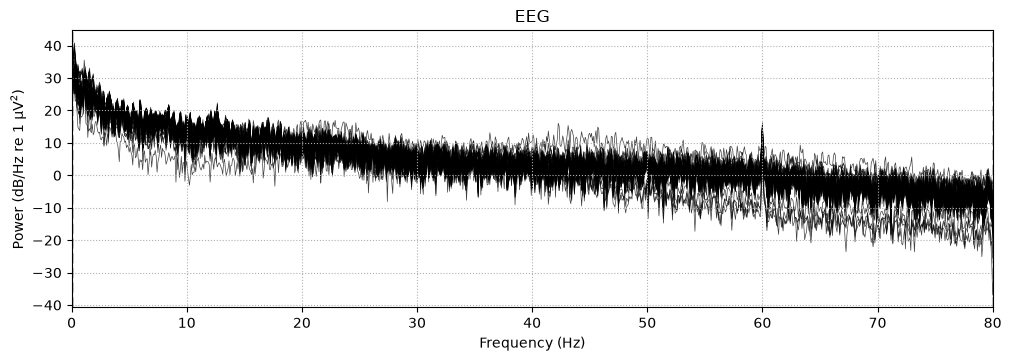

In [7]:
raw.plot_psd(fmax=80)


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)



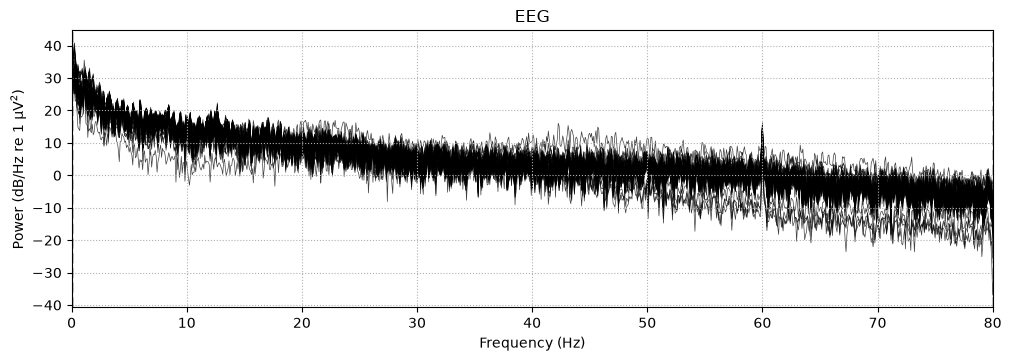

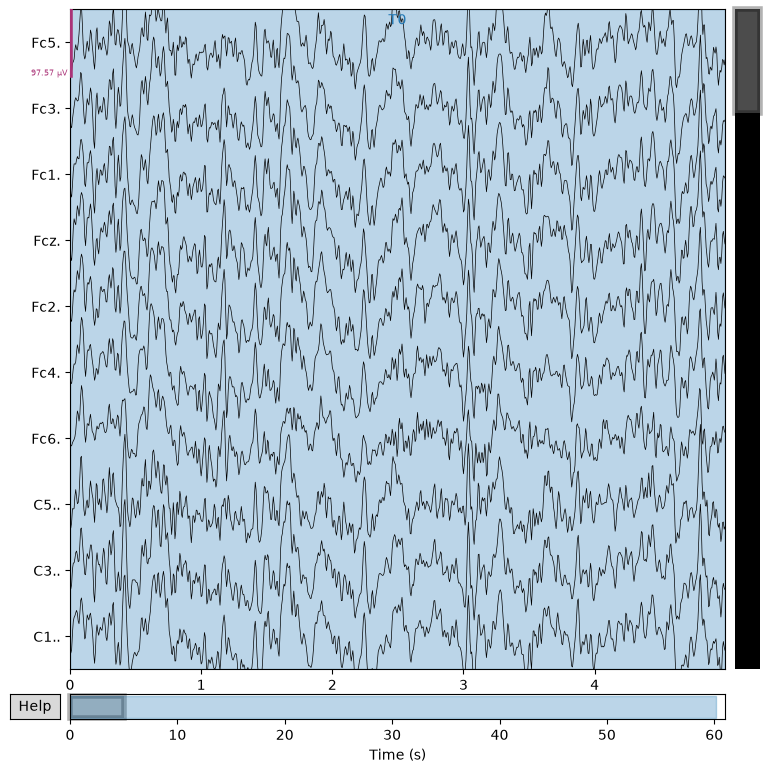

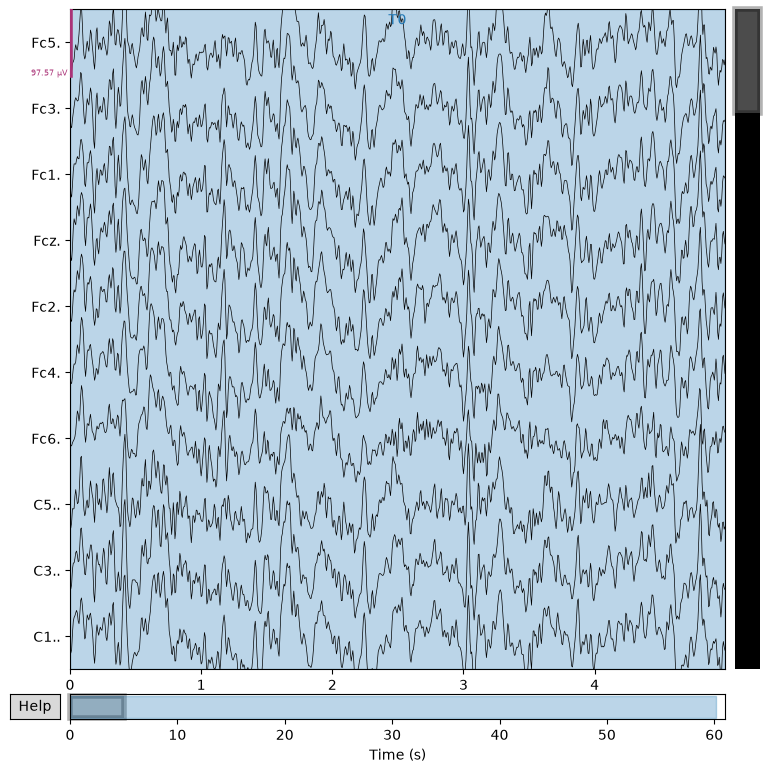

In [8]:
raw_notched = raw_filtered.copy().notch_filter(freqs=[60])
raw_notched.plot(n_channels=10, duration=5, scalings='auto')


In [9]:
import numpy as np
import mne

# Use the filtered + notch-cleaned signal
data = raw_notched.get_data()
sfreq = raw_notched.info['sfreq']

# Compute PSD using Welch method
psds, freqs = mne.time_frequency.psd_array_welch(
    data, 
    sfreq=sfreq, 
    fmin=1, 
    fmax=45,
    n_fft=1024
)

# Helper function to compute band power
def band_power(psds, freqs, fmin, fmax):
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return psds[:, idx].mean(axis=1)

# Extract EEG bands
delta = band_power(psds, freqs, 1, 4)
theta = band_power(psds, freqs, 4, 8)
alpha = band_power(psds, freqs, 8, 12)
beta  = band_power(psds, freqs, 12, 30)
gamma = band_power(psds, freqs, 30, 45)

delta, theta, alpha, beta, gamma


Effective window size : 6.400 (s)


(array([2.73265156e-10, 2.76573371e-10, 2.83588955e-10, 2.63786546e-10,
        2.48447024e-10, 2.09941299e-10, 1.87319888e-10, 1.81913437e-10,
        2.16865693e-10, 2.27301509e-10, 2.36787167e-10, 2.05611832e-10,
        1.63276178e-10, 1.15552943e-10, 1.86566557e-10, 2.14298559e-10,
        2.30099801e-10, 2.37170925e-10, 2.05909802e-10, 1.80548288e-10,
        1.28436139e-10, 1.50571448e-09, 1.14206017e-09, 1.36671428e-09,
        1.19389013e-09, 1.11592729e-09, 5.02257256e-10, 6.34066517e-10,
        1.22049926e-09, 4.31234968e-10, 4.92987906e-10, 3.82728416e-10,
        3.77830713e-10, 3.63112912e-10, 3.49389707e-10, 3.26809471e-10,
        3.57134771e-10, 5.06964482e-10, 2.46644420e-10, 1.37905534e-10,
        1.80103039e-10, 8.27120018e-11, 1.53106802e-10, 4.00486894e-11,
        1.53468665e-10, 7.42491602e-11, 1.63854917e-10, 1.97583158e-10,
        2.23355927e-10, 2.36025739e-10, 2.50187939e-10, 2.18771351e-10,
        1.85696805e-10, 1.45249080e-10, 1.11121979e-10, 2.028580

In [10]:
import pandas as pd

channels = raw_notched.info['ch_names']

df = pd.DataFrame({
    'channel': channels,
    'delta': delta,
    'theta': theta,
    'alpha': alpha,
    'beta': beta,
    'gamma': gamma
})

df


,channel,delta,theta,alpha,beta,gamma
0,Fc5.,2.732652e-10,5.591228e-11,2.559121e-11,1.220698e-11,2.774546e-12
1,Fc3.,2.765734e-10,6.359137e-11,3.214327e-11,1.474977e-11,2.334892e-12
2,Fc1.,2.835890e-10,7.178706e-11,3.375207e-11,1.409634e-11,2.108640e-12
3,Fcz.,2.637865e-10,7.729928e-11,3.403312e-11,1.379888e-11,2.111345e-12
4,Fc2.,2.484470e-10,6.872111e-11,3.073390e-11,1.278286e-11,1.919066e-12
...,...,...,...,...,...,...
59,Po8.,1.973624e-10,4.342768e-11,3.126302e-11,1.327035e-11,2.424261e-12
60,O1..,2.246426e-10,5.685095e-11,4.544225e-11,1.958555e-11,1.778918e-12
61,Oz..,2.415311e-10,5.453556e-11,4.185011e-11,1.760278e-11,2.126561e-12
62,O2..,2.688669e-10,5.577408e-11,4.163277e-11,1.883756e-11,2.372000e-12


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select only numeric features
X = df[['delta', 'theta', 'alpha', 'beta', 'gamma']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simple unsupervised model (no labels needed)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['cluster'] = labels
df


,channel,delta,theta,alpha,beta,gamma,cluster
0,Fc5.,2.732652e-10,5.591228e-11,2.559121e-11,1.220698e-11,2.774546e-12,1
1,Fc3.,2.765734e-10,6.359137e-11,3.214327e-11,1.474977e-11,2.334892e-12,1
2,Fc1.,2.835890e-10,7.178706e-11,3.375207e-11,1.409634e-11,2.108640e-12,1
3,Fcz.,2.637865e-10,7.729928e-11,3.403312e-11,1.379888e-11,2.111345e-12,1
4,Fc2.,2.484470e-10,6.872111e-11,3.073390e-11,1.278286e-11,1.919066e-12,1
...,...,...,...,...,...,...,...
59,Po8.,1.973624e-10,4.342768e-11,3.126302e-11,1.327035e-11,2.424261e-12,1
60,O1..,2.246426e-10,5.685095e-11,4.544225e-11,1.958555e-11,1.778918e-12,1
61,Oz..,2.415311e-10,5.453556e-11,4.185011e-11,1.760278e-11,2.126561e-12,1
62,O2..,2.688669e-10,5.577408e-11,4.163277e-11,1.883756e-11,2.372000e-12,1


In [12]:
import numpy as np
import pandas as pd

# Create a what-if perturbation: amplify alpha band
alpha_boost = alpha * 1.8

# Create a what-if perturbation: reduce beta band
beta_drop = beta * 0.6

# Build simulated brain state
df_simulated = pd.DataFrame({
    'channel': channels,
    'delta': delta,
    'theta': theta,
    'alpha_simulated': alpha_boost,
    'beta_simulated': beta_drop,
    'gamma': gamma
})

df_simulated


,channel,delta,theta,alpha_simulated,beta_simulated,gamma
0,Fc5.,2.732652e-10,5.591228e-11,4.606418e-11,7.324186e-12,2.774546e-12
1,Fc3.,2.765734e-10,6.359137e-11,5.785789e-11,8.849864e-12,2.334892e-12
2,Fc1.,2.835890e-10,7.178706e-11,6.075372e-11,8.457804e-12,2.108640e-12
3,Fcz.,2.637865e-10,7.729928e-11,6.125961e-11,8.279330e-12,2.111345e-12
4,Fc2.,2.484470e-10,6.872111e-11,5.532103e-11,7.669718e-12,1.919066e-12
...,...,...,...,...,...,...
59,Po8.,1.973624e-10,4.342768e-11,5.627344e-11,7.962212e-12,2.424261e-12
60,O1..,2.246426e-10,5.685095e-11,8.179604e-11,1.175133e-11,1.778918e-12
61,Oz..,2.415311e-10,5.453556e-11,7.533020e-11,1.056167e-11,2.126561e-12
62,O2..,2.688669e-10,5.577408e-11,7.493899e-11,1.130254e-11,2.372000e-12


In [13]:
import pandas as pd

comparison = pd.DataFrame({
    'channel': channels,
    'alpha_real': alpha,
    'alpha_simulated': df_simulated['alpha_simulated'],
    'beta_real': beta,
    'beta_simulated': df_simulated['beta_simulated']
})

comparison


,channel,alpha_real,alpha_simulated,beta_real,beta_simulated
0,Fc5.,2.559121e-11,4.606418e-11,1.220698e-11,7.324186e-12
1,Fc3.,3.214327e-11,5.785789e-11,1.474977e-11,8.849864e-12
2,Fc1.,3.375207e-11,6.075372e-11,1.409634e-11,8.457804e-12
3,Fcz.,3.403312e-11,6.125961e-11,1.379888e-11,8.279330e-12
4,Fc2.,3.073390e-11,5.532103e-11,1.278286e-11,7.669718e-12
...,...,...,...,...,...
59,Po8.,3.126302e-11,5.627344e-11,1.327035e-11,7.962212e-12
60,O1..,4.544225e-11,8.179604e-11,1.958555e-11,1.175133e-11
61,Oz..,4.185011e-11,7.533020e-11,1.760278e-11,1.056167e-11
62,O2..,4.163277e-11,7.493899e-11,1.883756e-11,1.130254e-11


In [14]:
comparison['alpha_change'] = comparison['alpha_simulated'] - comparison['alpha_real']
comparison['beta_change'] = comparison['beta_simulated'] - comparison['beta_real']

comparison


,channel,alpha_real,alpha_simulated,beta_real,beta_simulated,alpha_change,beta_change
0,Fc5.,2.559121e-11,4.606418e-11,1.220698e-11,7.324186e-12,2.047297e-11,-4.882791e-12
1,Fc3.,3.214327e-11,5.785789e-11,1.474977e-11,8.849864e-12,2.571462e-11,-5.899909e-12
2,Fc1.,3.375207e-11,6.075372e-11,1.409634e-11,8.457804e-12,2.700165e-11,-5.638536e-12
3,Fcz.,3.403312e-11,6.125961e-11,1.379888e-11,8.279330e-12,2.722650e-11,-5.519553e-12
4,Fc2.,3.073390e-11,5.532103e-11,1.278286e-11,7.669718e-12,2.458712e-11,-5.113146e-12
...,...,...,...,...,...,...,...
59,Po8.,3.126302e-11,5.627344e-11,1.327035e-11,7.962212e-12,2.501042e-11,-5.308141e-12
60,O1..,4.544225e-11,8.179604e-11,1.958555e-11,1.175133e-11,3.635380e-11,-7.834220e-12
61,Oz..,4.185011e-11,7.533020e-11,1.760278e-11,1.056167e-11,3.348009e-11,-7.041112e-12
62,O2..,4.163277e-11,7.493899e-11,1.883756e-11,1.130254e-11,3.330622e-11,-7.535024e-12


In [15]:
# Sort channels by alpha change (descending)
alpha_rank = comparison.sort_values('alpha_change', ascending=False)

# Sort channels by beta change (descending)
beta_rank = comparison.sort_values('beta_change', ascending=False)

alpha_rank, beta_rank


(   channel    alpha_real  alpha_simulated     beta_real  beta_simulated  \
 60    O1..  4.544225e-11     8.179604e-11  1.958555e-11    1.175133e-11   
 56    Po3.  4.272378e-11     7.690281e-11  1.511200e-11    9.067202e-12   
 57    Poz.  4.195968e-11     7.552742e-11  1.384832e-11    8.308994e-12   
 61    Oz..  4.185011e-11     7.533020e-11  1.760278e-11    1.056167e-11   
 62    O2..  4.163277e-11     7.493899e-11  1.883756e-11    1.130254e-11   
 ..     ...           ...              ...           ...             ...   
 13    C6..  1.677697e-11     3.019854e-11  7.584824e-12    4.550895e-12   
 45    Tp8.  1.185327e-11     2.133588e-11  4.774495e-12    2.864697e-12   
 39    Ft8.  1.090898e-11     1.963616e-11  5.431105e-12    3.258663e-12   
 41    T8..  9.632532e-12     1.733856e-11  1.497813e-11    8.986880e-12   
 43    T10.  2.996495e-12     5.393691e-12  3.809983e-12    2.285990e-12   
 
     alpha_change   beta_change  
 60  3.635380e-11 -7.834220e-12  
 56  3.417903e-11 

In [16]:
import numpy as np

# Compute perturbation sensitivity score
comparison['perturbation_score'] = (
    np.abs(comparison['alpha_change']) + np.abs(comparison['beta_change'])
)

# Sort channels by sensitivity
perturbation_rank = comparison.sort_values('perturbation_score', ascending=False)

perturbation_rank


,channel,alpha_real,alpha_simulated,beta_real,beta_simulated,alpha_change,beta_change,perturbation_score
60,O1..,4.544225e-11,8.179604e-11,1.958555e-11,1.175133e-11,3.635380e-11,-7.834220e-12,4.418802e-11
62,O2..,4.163277e-11,7.493899e-11,1.883756e-11,1.130254e-11,3.330622e-11,-7.535024e-12,4.084124e-11
61,Oz..,4.185011e-11,7.533020e-11,1.760278e-11,1.056167e-11,3.348009e-11,-7.041112e-12,4.052120e-11
56,Po3.,4.272378e-11,7.690281e-11,1.511200e-11,9.067202e-12,3.417903e-11,-6.044801e-12,4.022383e-11
55,Po7.,4.146006e-11,7.462810e-11,1.546290e-11,9.277742e-12,3.316805e-11,-6.185161e-12,3.935321e-11
...,...,...,...,...,...,...,...,...
13,C6..,1.677697e-11,3.019854e-11,7.584824e-12,4.550895e-12,1.342157e-11,-3.033930e-12,1.645550e-11
41,T8..,9.632532e-12,1.733856e-11,1.497813e-11,8.986880e-12,7.706025e-12,-5.991253e-12,1.369728e-11
45,Tp8.,1.185327e-11,2.133588e-11,4.774495e-12,2.864697e-12,9.482613e-12,-1.909798e-12,1.139241e-11
39,Ft8.,1.090898e-11,1.963616e-11,5.431105e-12,3.258663e-12,8.727184e-12,-2.172442e-12,1.089963e-11


In [17]:
import numpy as np

comparison['perturbation_score'] = (
    np.abs(comparison['alpha_change']) + np.abs(comparison['beta_change'])
)

perturbation_rank = comparison.sort_values('perturbation_score', ascending=False)

perturbation_rank


,channel,alpha_real,alpha_simulated,beta_real,beta_simulated,alpha_change,beta_change,perturbation_score
60,O1..,4.544225e-11,8.179604e-11,1.958555e-11,1.175133e-11,3.635380e-11,-7.834220e-12,4.418802e-11
62,O2..,4.163277e-11,7.493899e-11,1.883756e-11,1.130254e-11,3.330622e-11,-7.535024e-12,4.084124e-11
61,Oz..,4.185011e-11,7.533020e-11,1.760278e-11,1.056167e-11,3.348009e-11,-7.041112e-12,4.052120e-11
56,Po3.,4.272378e-11,7.690281e-11,1.511200e-11,9.067202e-12,3.417903e-11,-6.044801e-12,4.022383e-11
55,Po7.,4.146006e-11,7.462810e-11,1.546290e-11,9.277742e-12,3.316805e-11,-6.185161e-12,3.935321e-11
...,...,...,...,...,...,...,...,...
13,C6..,1.677697e-11,3.019854e-11,7.584824e-12,4.550895e-12,1.342157e-11,-3.033930e-12,1.645550e-11
41,T8..,9.632532e-12,1.733856e-11,1.497813e-11,8.986880e-12,7.706025e-12,-5.991253e-12,1.369728e-11
45,Tp8.,1.185327e-11,2.133588e-11,4.774495e-12,2.864697e-12,9.482613e-12,-1.909798e-12,1.139241e-11
39,Ft8.,1.090898e-11,1.963616e-11,5.431105e-12,3.258663e-12,8.727184e-12,-2.172442e-12,1.089963e-11


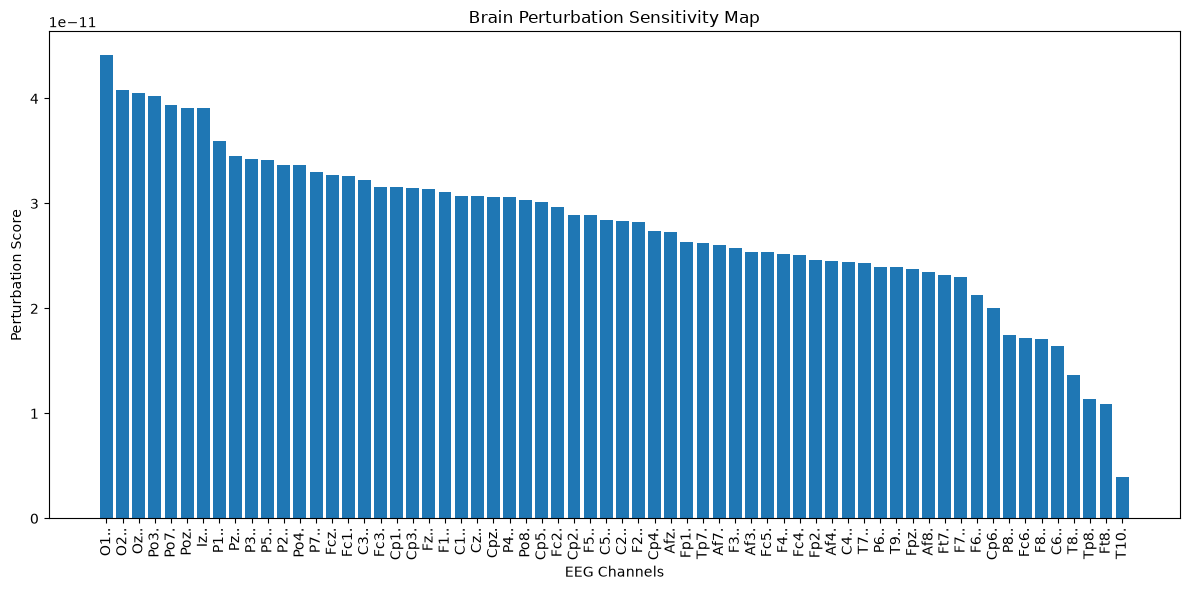

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(perturbation_rank['channel'], perturbation_rank['perturbation_score'])
plt.xticks(rotation=90)
plt.title('Brain Perturbation Sensitivity Map')
plt.ylabel('Perturbation Score')
plt.xlabel('EEG Channels')
plt.tight_layout()
plt.show()
